# Programas sociais federais: escala, cobertura e evolução do BPC

Este estudo reúne indicadores oficiais agregados do **Benefício de Prestação Continuada (BPC)**, do **Bolsa Família (PBF)** e do **Auxílio Gás**. A série histórica comparável mais longa disponível na tabela usada é a do BPC, de 2004 a 2024. Para Bolsa Família e Auxílio Gás, o balanço do MDS oferece medidas de escala em 2024.

**Perguntas:** como cresceu a cobertura e o valor repassado pelo BPC? Como se compara sua escala financeira com a do Bolsa Família?

Não se somam beneficiários de BPC a famílias do Bolsa Família: as unidades são diferentes e há possível sobreposição de pessoas. Valores são nominais, salvo indicação. Fonte principal: [VIS DATA/MDS — série anual do BPC](https://aplicacoes.cidadania.gov.br/vis/data3/v.php?ma=ano&q%5B%5D=r6C5ZNnryaG4emVqrWZ9f2RdiJxlmm9niquBYWx5sZzpnKy%2Bp5G2w5jYeJm%2B58CZd7ynr950iMKporycbt2yoIDdvZebsZmp7KissJybkseU1rCYmO%2B%2FqaGDcK7rrrKJcqDMzlbMrZa8672Ym76hde2rwrNyocnWmKV4p8%2Fwsm93u6qnnJu9sZaWu9Cm2ZypybbBprGtcK7rrrKJcqHJ1pileKbS6HCvXauWrd5ZxLacm3fEosupmNDeslx8qqWd2Km9spaPvM9fmmZTiJuwo520mq3cnnWOmZ26wJzOrKbM2q%2BZqnRlY5l3bX5Xob%2FGoYqgor7nsqefrV1626mwraedu8CVz6tfjaRtX1yrpJvlnsCxnFWXw6PNnJzB6sCjm6qaqKVpdm6cmcrGU9iyn8mbsqKgabJ135q5wZxoy9Ooz3huw9y5p6GDcK3upnDJWJC41JiKtJvC6W2Xq6mhn%2BycsnZ3j8fEktqtl7zxuWBscVVlmZy8r6OSysSYkn2Vzd6snaC3qKnYr7l6Z1Z3n1OaXafF4LtUn7eWpt6ssLNfbbnRlsmto8Haw6BoeF5apFmwvZiZvNSWz2Vzv%2Buwk6WspK3omMO6Y12AgZjWsJh96cKgqGiaqN1ayomrn8zGbt6vqMK2iJqdtKiftHTAw6Spp8am3ayU0Juwo6loeZ%2FforC3%2BtfFxJzLXVutvpFdXKqaqN6ftrGg8PjTnMuwU8HqbXaMi1iD3ajAvapNucahz6OcwOQQ1a6xpK2ZnbxueX2ahInLqaLPm5%2BZrKmordqdvG6YTaekd91do8LnvFR%2BmHhdz5q5valNqcajy7Cmvt%2B8VJ1ofp7orLzBV528zaKKf4OgnqGjsKmhWt2ebZCcm7zHnM2m9v7ttqOvaJmpmXudkVqDuM2i3F2HzO%2BuoFy6mqrarMCvm5x3wqKKf4Og971vuMSxbKlpgXtnXoSRZL5tY5erfW5seI91) e [MDS — balanço do Bolsa Família 2024](https://www.gov.br/mds/pt-br/noticias-e-conteudos/desenvolvimento-social/noticias-desenvolvimento-social/governo-federal-repassa-r-168-3-bilhoes-pelo-bolsa-familia-em-2024).

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
DATA = ROOT / 'data' / 'processed'
bpc = pd.read_csv(DATA / 'bpc_historico_anual.csv')
bpc.head()

,ano,beneficiarios_pcd,beneficiarios_idosos,beneficiarios_total,repasse_pcd_brl,repasse_idosos_brl,repasse_total_brl
0,2004,1127849,933164,2061013,3.300027e+09,2.514256e+09,5.814283e+09
1,2005,1211761,1065604,2277365,4.054095e+09,3.469767e+09,7.523861e+09
2,2006,1293645,1183840,2477485,5.112542e+09,4.606246e+09,9.718788e+09
3,2007,1385107,1295716,2680823,5.987030e+09,5.561315e+09,1.154834e+10
4,2008,1510682,1423790,2934472,7.110730e+09,6.675058e+09,1.378579e+10


## 1. Evolução da cobertura e dos repasses do BPC

O BPC garante um salário mínimo mensal a pessoas idosas (65 anos ou mais) ou pessoas com deficiência que atendam aos critérios legais de renda. A coluna de beneficiários é o total anual publicado pelo MDS; o valor repassado é soma anual nominal.

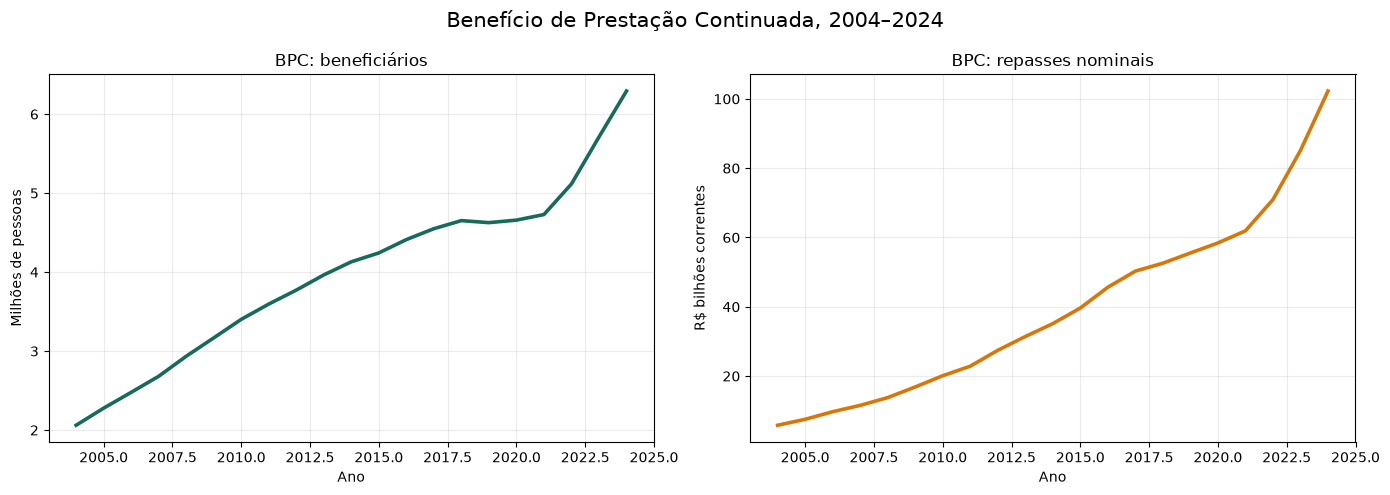

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(bpc['ano'], bpc['beneficiarios_total'] / 1e6, color='#176b5b', lw=2.6)
ax[0].set(title='BPC: beneficiários', xlabel='Ano', ylabel='Milhões de pessoas')
ax[0].grid(alpha=.25)
ax[1].plot(bpc['ano'], bpc['repasse_total_brl'] / 1e9, color='#d97706', lw=2.6)
ax[1].set(title='BPC: repasses nominais', xlabel='Ano', ylabel='R$ bilhões correntes')
ax[1].grid(alpha=.25)
fig.suptitle('Benefício de Prestação Continuada, 2004–2024', fontsize=15)
plt.tight_layout()
plt.show()

In [3]:
inicio, fim = bpc.iloc[0], bpc.iloc[-1]
resumo = pd.DataFrame({
    'Indicador': ['Beneficiários', 'Repasses nominais'],
    '2004': [inicio['beneficiarios_total'], inicio['repasse_total_brl']],
    '2024': [fim['beneficiarios_total'], fim['repasse_total_brl']],
    'Variação acumulada (%)': [
        (fim['beneficiarios_total'] / inicio['beneficiarios_total'] - 1) * 100,
        (fim['repasse_total_brl'] / inicio['repasse_total_brl'] - 1) * 100,
    ],
})
display(resumo.style.format({'2004':'{:,.0f}', '2024':'{:,.0f}', 'Variação acumulada (%)':'{:.1f}%'}))
print(f"Variação de beneficiários em 2024: {(fim['beneficiarios_total']/bpc.iloc[-2]['beneficiarios_total']-1)*100:.1f}%")
print(f"Repasse de 2024 por beneficiário registrado no total anual (aproximação): R$ {fim['repasse_total_brl']/fim['beneficiarios_total']:,.0f}")

,Indicador,2004,2024,Variação acumulada (%)
0,Beneficiários,"2,061,013","6,292,449",205.3%
1,Repasses nominais,"5,814,283,018","102,269,367,070",1658.9%


Variação de beneficiários em 2024: 10.2%
Repasse de 2024 por beneficiário registrado no total anual (aproximação): R$ 16,253


## 2. Quem recebe o BPC?

A série distingue pessoas com deficiência e pessoas idosas. As quantidades são totais anuais publicados pelo painel, não novas concessões durante o ano.

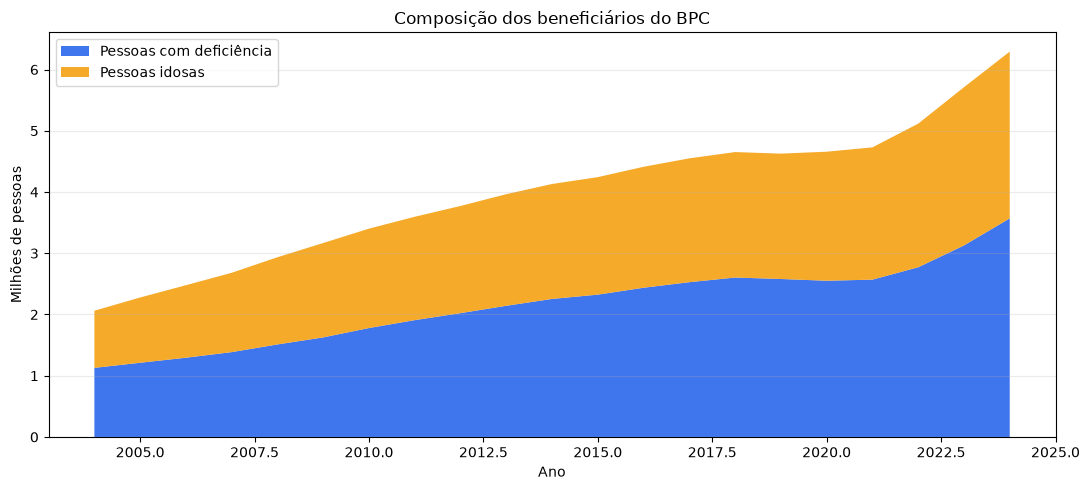

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.stackplot(bpc['ano'], bpc['beneficiarios_pcd']/1e6, bpc['beneficiarios_idosos']/1e6,
             labels=['Pessoas com deficiência', 'Pessoas idosas'], colors=['#2563eb','#f59e0b'], alpha=.88)
ax.set(title='Composição dos beneficiários do BPC', xlabel='Ano', ylabel='Milhões de pessoas')
ax.legend(loc='upper left'); ax.grid(axis='y', alpha=.25)
plt.tight_layout(); plt.show()

## 3. Escala financeira de grandes programas em 2024

O MDS informou R$ 168,3 bilhões em repasses do Bolsa Família em 2024. Para o BPC, esta análise usa o total anual de R$ 102,27 bilhões calculado pela série histórica do VIS Data. A diferença frente a outras publicações do MDS pode decorrer de conceito ou perímetro contábil; por isso, os números são apresentados com fonte explícita. O Auxílio Gás é bimestral: o MDS informa cobertura média de 5,7 milhões de famílias em cada ciclo em 2024; essa cobertura não é diretamente comparável ao total anual de famílias do Bolsa Família nem ao número de pessoas beneficiárias do BPC.

,Programa,Repasses em 2024 (R$ bilhões correntes),Unidade de cobertura divulgada,Cobertura publicada
0,Bolsa Família,168.300000,famílias atendidas ao longo do ano,"mais de 20,86 milhões"
1,BPC,102.269367,pessoas beneficiárias,6.292.449


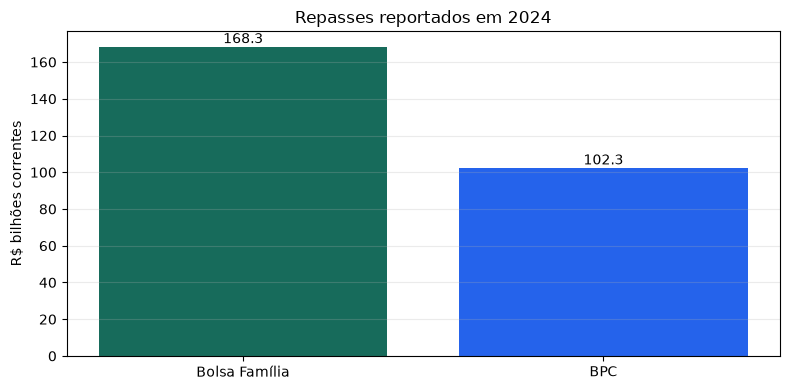

In [5]:
comparacao = pd.DataFrame({
    'Programa': ['Bolsa Família', 'BPC'],
    'Repasses em 2024 (R$ bilhões correntes)': [168.3, float(fim['repasse_total_brl'])/1e9],
    'Unidade de cobertura divulgada': ['famílias atendidas ao longo do ano', 'pessoas beneficiárias'],
    'Cobertura publicada': ['mais de 20,86 milhões', '6.292.449'],
})
display(comparacao)
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(comparacao['Programa'], comparacao['Repasses em 2024 (R$ bilhões correntes)'], color=['#176b5b','#2563eb'])
ax.set(title='Repasses reportados em 2024', ylabel='R$ bilhões correntes')
ax.grid(axis='y', alpha=.25)
for i, v in enumerate(comparacao['Repasses em 2024 (R$ bilhões correntes)']): ax.text(i,v+2,f'{v:.1f}',ha='center')
plt.tight_layout(); plt.show()

### Auxílio Gás em contexto

Em 2024, o MDS informou que o Auxílio Gás atendeu em média 5,7 milhões de famílias por ciclo bimestral entre fevereiro e dezembro. É uma fotografia de cobertura por ciclo, não número de famílias únicas no ano. O benefício cobre parte ou a totalidade do preço de referência do botijão de GLP conforme a regra vigente. Fonte: [Relatório de Gestão MDS 2024](https://www.gov.br/mds/pt-br/acesso-a-informacao/auditorias/2024/mds-relatorio-de-gestao.pdf).

## Síntese e limites

- Entre 2004 e 2024, beneficiários do BPC passaram de 2,06 milhões para 6,29 milhões; repasses nominais cresceram de R$ 5,81 bilhões para R$ 102,27 bilhões. Crescimento nominal combina expansão da cobertura, reajustes do salário mínimo e inflação; não equivale a crescimento real do poder de compra.
- A aceleração dos repasses depois de 2021 também reflete mudanças no salário mínimo e no número de beneficiários. A análise não atribui causalidade a uma política específica.
- O Bolsa Família alcançou uma ordem de gasto maior em 2024, mas os programas atendem públicos e unidades de cobertura diferentes. O gasto do Bolsa Família é de famílias; BPC é benefício individual.
- A comparação não inclui benefícios previdenciários do RGPS, que têm escala fiscal ainda maior e exigem outra definição analítica.
- Painéis administrativos podem ser revisados. Os dados do BPC estão preservados localmente para reprodutibilidade e devem ser conferidos na fonte antes de uso fiscal oficial.

## Fontes e proveniência

1. **MDS/SAGICAD, VIS DATA 3 — Série histórica anual do BPC** (Brasil, 2004–2024): contagens e repasses por grupo. Consulta acessada em 6 out. 2026.
2. **MDS — Governo Federal repassa R$ 168,3 bilhões pelo Bolsa Família em 2024**: total de repasses e famílias alcançadas no ano.
3. **MDS — Relatório de Gestão 2024**: cobertura média bimestral do Auxílio Gás e síntese institucional.

O arquivo `data/processed/bpc_historico_anual.csv` contém a transcrição da tabela VIS Data usada nesta análise. Não foram usados registros individualizados, CPFs ou NIS.